# BPP pretrained reproduction

This notebook runs the unified DeepACO reproduction entry point for this problem. It writes logs, raw JSON, Markdown tables, and PNG figures to the repository-level output folders.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'pretrained').exists() else cwd.parent
sys.path.insert(0, str(ROOT))

from scripts.reproduce_problem import run_problem

PROBLEM = 'bpp'
DEVICE = 'auto'          # 'auto', 'cpu', 'cuda', or 'cuda:0'
SEED = 12345
LIMIT_INSTANCES = None   # set to a small integer for a quick smoke test
SIZES = None             # e.g. [20] or None for all configured scales
T_ACO = None             # e.g. [1, 10] or None for paper-style checkpoints
METHODS = None           # e.g. ['deepaco'] or ['deepaco', 'aco']
INCLUDE_BASELINE = True


e:\DeepAoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw = run_problem(
    PROBLEM,
    sizes=SIZES,
    t_aco=T_ACO,
    methods=METHODS,
    limit_instances=LIMIT_INSTANCES,
    device=DEVICE,
    seed=SEED,
    include_baseline=INCLUDE_BASELINE,
)
raw['outputs']


[2026-05-11T09:46:33] Starting BPP reproduction
[2026-05-11T09:46:33] sizes=[120], t_aco=[1, 5, 10, 20], methods=['deepaco', 'aco'], device=cpu
[2026-05-11T09:46:35] BPP120: 100/100 instances
[2026-05-11T09:49:51] Finished BPP 120 DeepACO in 195.21s
[2026-05-11T09:52:58] Finished BPP 120 ACO in 186.78s
[2026-05-11T09:53:00] Wrote raw results: results/raw/bpp_results.json
[2026-05-11T09:53:00] Wrote table: results/tables/bpp_table.md
[2026-05-11T09:53:00] Wrote figure: results/figures/bpp_comparison.png


{'raw': 'results/raw/bpp_results.json',
 'table': 'results/tables/bpp_table.md',
 'figure': 'results/figures/bpp_comparison.png',
 'log': 'logs/bpp.log'}

# BPP Reproduction Table

- Metric: average fitness (higher is better)
- Instances per completed row: see `instances` column
- Device: cpu

| scale | method | status | instances | duration_s | T=1 | T=5 | T=10 | T=20 | gap_vs_aco_last |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 120 | DeepACO | ok | 100 | 195.21 | 0.945207 | 0.951165 | 0.953934 | 0.955825 | +5.33% |
| 120 | ACO | ok | 100 | 186.78 | 0.877262 | 0.894383 | 0.901391 | 0.907417 |  |


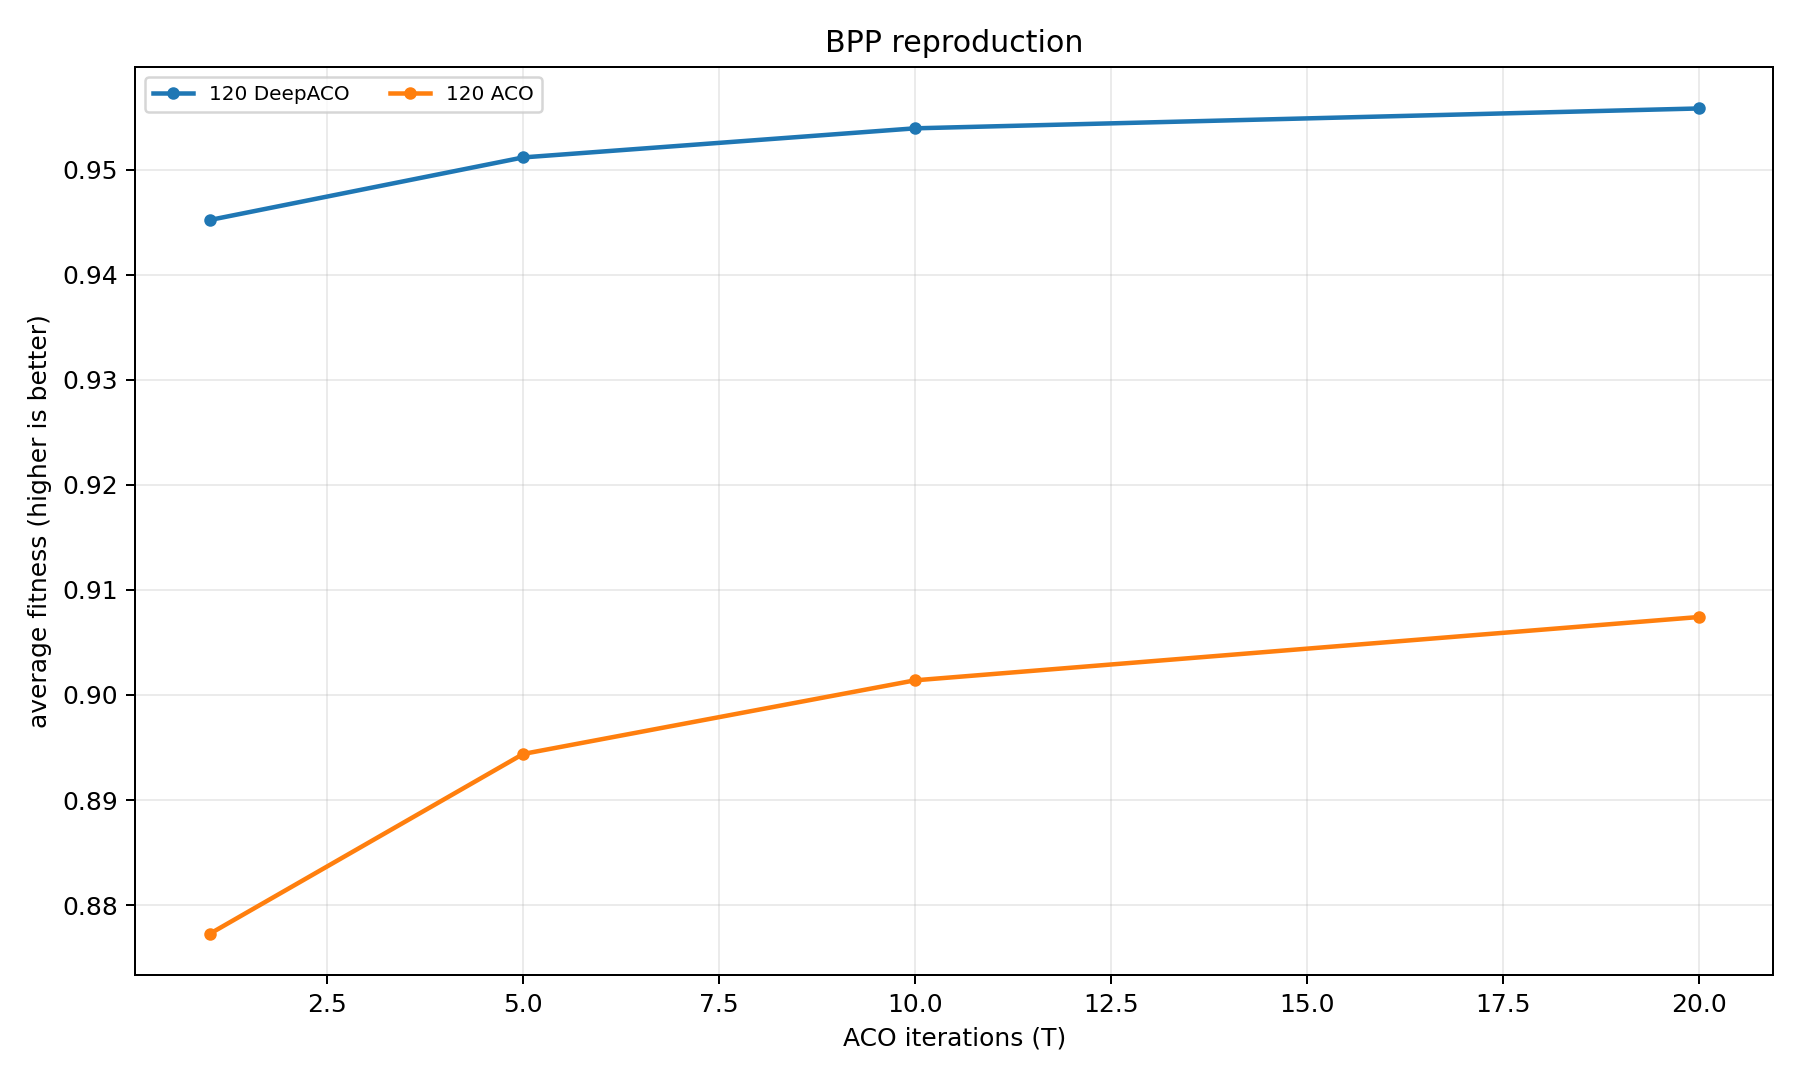

In [3]:
from IPython.display import Image, Markdown, display

outputs = raw['outputs'] if 'raw' in globals() else {
    'table': f'results/tables/{PROBLEM}_table.md',
    'figure': f'results/figures/{PROBLEM}_comparison.png',
}

table_path = ROOT / outputs['table']
figure_path = ROOT / outputs['figure']

display(Markdown(table_path.read_text(encoding='utf-8')))
display(Image(filename=str(figure_path)))
